# Strategi Portofolio Berbasis Graph Neural Networks (GNN)
## GNN Graph Diversification - Implementasi & Evaluasi

Notebook ini mengimplementasikan strategi alokasi portofolio menggunakan **GNN Graph Diversification**.
Model menggunakan *Graph Convolutional Networks* (GCN) untuk mempelajari dependensi antar aset kripto
secara non-linier dan membangun graf korelasi prediktif melalui *Maximum Independent Set* (MIS).

**Varian yang diuji:**
- GNN Graph Diversification (30 Epoch)
- GNN Graph Diversification (50 Epoch)
- GNN Graph Diversification (100 Epoch)

---
## Sel 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print('Libraries loaded successfully!')
print(f'PyTorch version : {torch.__version__}')

Libraries loaded successfully!
PyTorch version : 2.9.1+cpu


---
## Sel 2 — Load & Prepare Data Kripto

In [2]:
EXCEL_FILE = 'crypto_data_real.xlsx'

df_raw = pd.read_excel(EXCEL_FILE, sheet_name='Returns', index_col=0)
df_raw.index = pd.to_datetime(df_raw.index)
df_raw.sort_index(inplace=True)
df_raw = df_raw.drop(columns=['USDT'], errors='ignore')  # hapus stablecoin

# Hanya simpan baris di mana semua aset sudah aktif (return != 0)
mask = (df_raw != 0).all(axis=1)
df_returns = df_raw[mask].copy()

# Sub-period labels
BULL_END = '2017-12-31'   # Bull  : Nov 2017 - Des 2017
BEAR_END = '2018-12-31'   # Bear  : Jan 2018 - Des 2018
                           # Recovery: Jan 2019 - Okt 2019

periods = {
    'Bull (Nov-Dec 2017)' : df_returns.loc[df_returns.index <= BULL_END],
    'Bear (2018)'         : df_returns.loc[
                                (df_returns.index > BULL_END) &
                                (df_returns.index <= BEAR_END)],
    'Recovery (2019)'     : df_returns.loc[df_returns.index > BEAR_END],
    'Full Period'         : df_returns,
}

print('=== DATASET SUMMARY ===')
print(f'Assets  : {df_returns.columns.tolist()}')
print(f'Period  : {df_returns.index.min().date()} -> {df_returns.index.max().date()}')
print(f'Obs     : {len(df_returns)} trading days')
print()
for pname, pdf in periods.items():
    print(f'{pname:<25}: {len(pdf):>4} days')
print()
print(df_returns.describe().round(4))

=== DATASET SUMMARY ===
Assets  : ['BTC', 'ETH', 'XRP', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']
Period  : 2017-11-10 -> 2019-10-17
Obs     : 706 trading days

Bull (Nov-Dec 2017)      :   52 days
Bear (2018)              :  364 days
Recovery (2019)          :  290 days
Full Period              :  706 days

            BTC       ETH       XRP       BCH       LTC       BNB       EOS  \
count  706.0000  706.0000  706.0000  706.0000  706.0000  706.0000  706.0000   
mean     0.0002   -0.0008    0.0005   -0.0016   -0.0002    0.0032    0.0013   
std      0.0434    0.0527    0.0680    0.0752    0.0591    0.0645    0.0737   
min     -0.1846   -0.2069   -0.3520   -0.4096   -0.2119   -0.3424   -0.3015   
25%     -0.0173   -0.0237   -0.0267   -0.0336   -0.0287   -0.0258   -0.0306   
50%      0.0016   -0.0003   -0.0025   -0.0038   -0.0028    0.0000   -0.0005   
75%      0.0186    0.0248    0.0203    0.0256    0.0275    0.0310    0.0297   
max      0.2251    0.2347    0.6069    0.4316    0.3893   

---
## Sel 3 — Risk Metrics & Helper Functions

In [3]:
# ── Risk Metrics ─────────────────────────────────────────────────────────────

def calculate_var(returns, confidence=0.95):
    """Value at Risk pada level kepercayaan tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Rasio rata-rata tail atas terhadap tail bawah."""
    tu = np.percentile(returns, (1 - alpha) * 100)
    tl = np.percentile(returns, alpha * 100)
    cu = returns[returns >= tu].mean()
    cl = abs(returns[returns <= tl].mean())
    return cu / cl if cl > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Drawdown maksimum dari nilai kumulatif portofolio."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / (running_max + 1e-12)
    return drawdown.min()

def calculate_calmar_ratio(returns, cum_returns):
    """Calmar Ratio = Return Tahunan / |Max Drawdown|."""
    ann_ret = np.mean(returns) * 252
    mdd     = abs(calculate_max_drawdown(cum_returns))
    return ann_ret / mdd if mdd > 0 else 0

def diebold_mariano_test(returns_a, returns_b, h=1):
    """Uji Diebold-Mariano untuk perbandingan performa dua strategi."""
    T = len(returns_a)
    d = returns_a - returns_b
    d_mean = np.mean(d)

    def autocov(xi, xm, k):
        T_ = len(xi)
        return np.sum((xi[:T_-k] - xm) * (xi[k:] - xm)) / T_ if T_ > k else 0

    var_d = autocov(d, d_mean, 0)
    for i in range(1, h):
        var_d += 2 * autocov(d, d_mean, i)

    dm = d_mean / np.sqrt(abs(var_d) / T) if var_d != 0 else 0
    pv = 2 * (1 - stats.norm.cdf(abs(dm)))
    return dm, pv

print('Risk metrics & helper functions defined.')

Risk metrics & helper functions defined.


---
## Sel 4 — Arsitektur Graph Neural Network (GCN)

In [4]:
class CorrelationGNN(nn.Module):
    """
    2-layer Graph Convolutional Network untuk menghasilkan node embeddings.
    Korelasi antar aset diprediksi melalui cosine similarity di ruang laten.
    
    Arsitektur:
      Input  : 4 fitur node (Mean, Std, Skew, Kurt)
      Hidden : 16-dim
      Output : 8-dim latent embedding
    """
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=8):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return x

    def predict_correlation(self, emb):
        """Prediksi matriks korelasi via cosine similarity antar embedding."""
        n = emb.shape[0]
        C = torch.zeros(n, n)
        for i in range(n):
            for j in range(i + 1, n):
                s = F.cosine_similarity(
                    emb[i].unsqueeze(0),
                    emb[j].unsqueeze(0)
                )
                C[i, j] = C[j, i] = s
        for i in range(n):
            C[i, i] = 1.0
        return C


def create_graph_data(returns_window, corr_threshold=0.3):
    """
    Membuat objek PyTorch Geometric Data dari window return.
    
    Node features: [mean, std, skew, kurtosis]
    Edges        : pasangan aset dengan |korelasi| > corr_threshold
    Labels (y)   : matriks korelasi empiris
    """
    n = returns_window.shape[1]

    # Node features
    feats = np.stack([
        returns_window.mean().values,
        returns_window.std().values,
        returns_window.skew().values,
        returns_window.kurtosis().values
    ], axis=1)
    x = torch.FloatTensor(feats)

    # Edge construction
    corr = returns_window.corr().values
    edges = [
        [i, j]
        for i in range(n)
        for j in range(i + 1, n)
        if abs(corr[i, j]) > corr_threshold
    ]
    edges += [[j, i] for i, j in edges]  # undirected

    # Fallback: fully connected jika tidak ada edge
    if not edges:
        edges = [[i, j] for i in range(n) for j in range(n) if i != j]

    ei = torch.LongTensor(edges).t().contiguous()
    return Data(x=x, edge_index=ei, y=torch.FloatTensor(corr))


def train_gnn(model, data, epochs=30, lr=0.01):
    """
    Melatih model GNN menggunakan Adam Optimizer dan MSE Loss.
    Target: korelasi laten (predicted) ≈ korelasi empiris (label).
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()
    model.train()

    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        emb  = model(data.x, data.edge_index)
        pred = model.predict_correlation(emb)
        loss = loss_fn(pred, data.y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return model, losses


print('CorrelationGNN architecture defined.')
print(f'  Input  : 4 features (Mean, Std, Skew, Kurtosis)')
print(f'  Hidden : 16-dim')
print(f'  Output : 8-dim embedding')

CorrelationGNN architecture defined.
  Input  : 4 features (Mean, Std, Skew, Kurtosis)
  Hidden : 16-dim
  Output : 8-dim embedding


---
## Sel 5 — Demonstrasi Training GNN (Satu Window)

Menampilkan proses training pada satu window data untuk memverifikasi model berjalan dengan benar.

=== DEMO: GNN Training pada 1 Window ===
Window size : 120 hari
Assets      : 9

Graph Data  : Data(x=[9, 4], edge_index=[2, 64], y=[9, 9])
  Nodes     : 9
  Edges     : 64

GNN  30 epoch | Final Loss: 0.291641
GNN  50 epoch | Final Loss: 0.291851
GNN 100 epoch | Final Loss: 0.291851


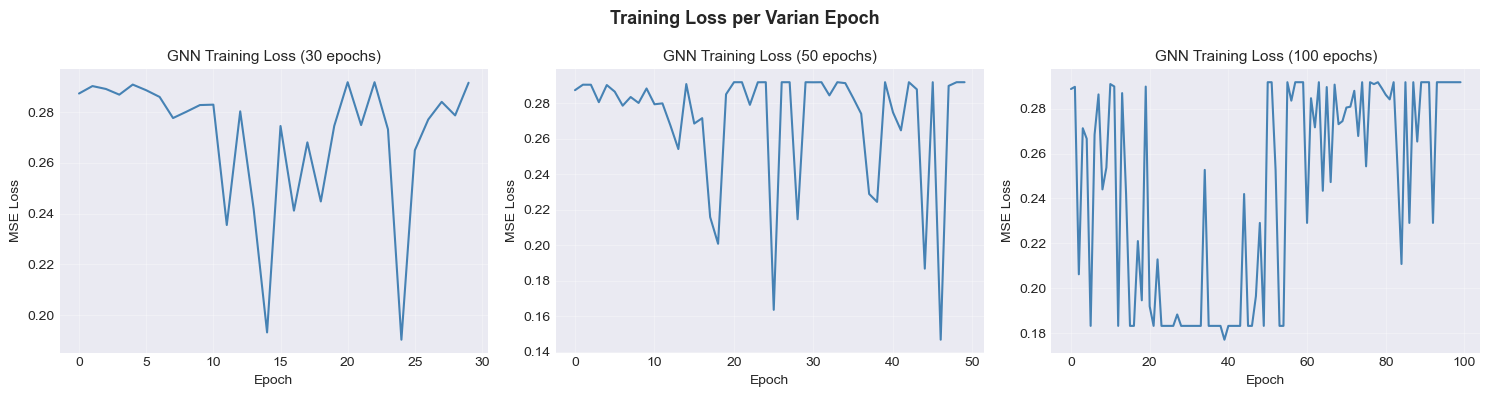

In [5]:
# Ambil window awal untuk demonstrasi
WINDOW_SIZE = 120
demo_window = df_returns.iloc[:WINDOW_SIZE]

print('=== DEMO: GNN Training pada 1 Window ===')
print(f'Window size : {WINDOW_SIZE} hari')
print(f'Assets      : {demo_window.shape[1]}')
print()

# Buat graph data
demo_data = create_graph_data(demo_window)
print(f'Graph Data  : {demo_data}')
print(f'  Nodes     : {demo_data.num_nodes}')
print(f'  Edges     : {demo_data.num_edges}')
print()

# Training dengan 3 varian epoch
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
variants = [30, 50, 100]

for ax, ep in zip(axes, variants):
    model = CorrelationGNN()
    model, losses = train_gnn(model, demo_data, epochs=ep, lr=0.01)
    ax.plot(losses, color='steelblue', linewidth=1.5)
    ax.set_title(f'GNN Training Loss ({ep} epochs)', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.grid(True, alpha=0.3)
    print(f'GNN {ep:>3} epoch | Final Loss: {losses[-1]:.6f}')

plt.suptitle('Training Loss per Varian Epoch', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gnn_training_loss.png', dpi=150)
plt.show()

---
## Sel 6 — Visualisasi Predicted Correlation Matrix

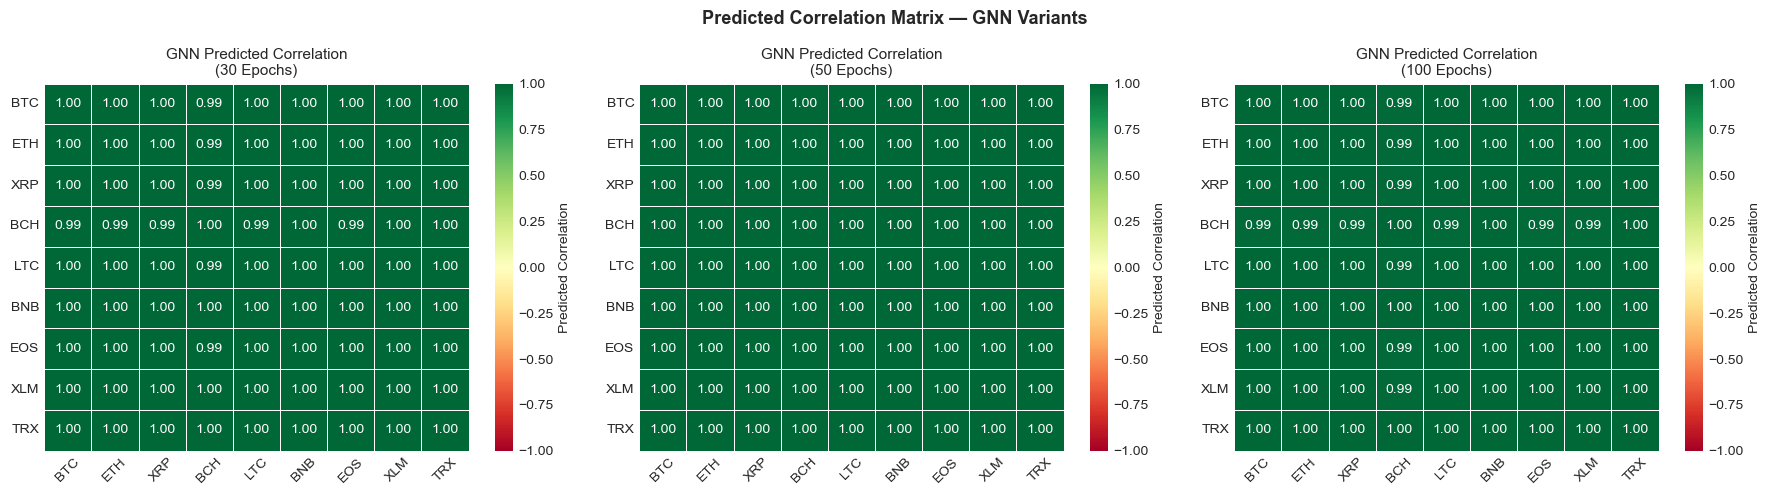

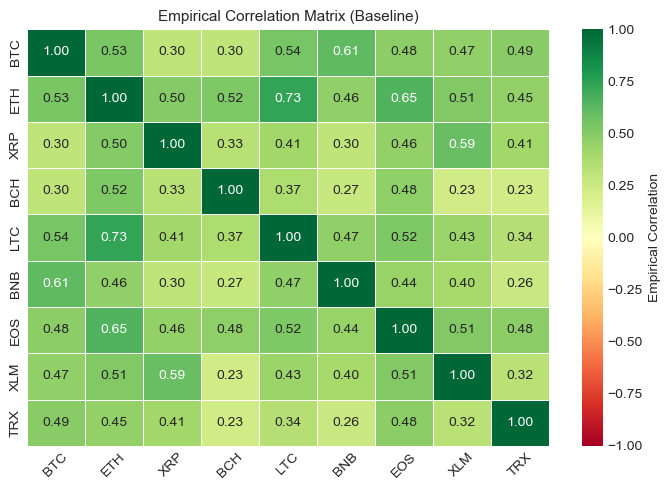

In [6]:
asset_names = df_returns.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ep in zip(axes, [30, 50, 100]):
    model = CorrelationGNN()
    model, _ = train_gnn(model, demo_data, epochs=ep)
    model.eval()

    with torch.no_grad():
        emb  = model(demo_data.x, demo_data.edge_index)
        pred_corr = model.predict_correlation(emb).numpy()

    sns.heatmap(
        pred_corr,
        ax=ax,
        xticklabels=asset_names,
        yticklabels=asset_names,
        cmap='RdYlGn',
        center=0,
        vmin=-1, vmax=1,
        annot=True, fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': 'Predicted Correlation'}
    )
    ax.set_title(f'GNN Predicted Correlation\n({ep} Epochs)', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Predicted Correlation Matrix — GNN Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gnn_predicted_correlation.png', dpi=150)
plt.show()

# Bandingkan dengan empiris
fig, ax = plt.subplots(figsize=(7, 5))
empirical_corr = demo_window.corr()
sns.heatmap(
    empirical_corr,
    ax=ax,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', linewidths=0.5,
    cbar_kws={'label': 'Empirical Correlation'}
)
ax.set_title('Empirical Correlation Matrix (Baseline)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('empirical_correlation.png', dpi=150)
plt.show()

---
## Sel 7 — GNN Graph Diversification Strategy Class

In [7]:
class PortfolioStrategy:
    """Kelas basis untuk semua strategi portofolio."""
    def __init__(self, name):
        self.name = name

    def get_weights(self, r):
        raise NotImplementedError


class GNNGraphDiversification(PortfolioStrategy):
    """
    Strategi alokasi portofolio berbasis GNN Graph Diversification.

    Langkah:
      1. Latih CorrelationGNN pada window return terkini.
      2. Prediksi matriks korelasi via cosine similarity embedding.
      3. Bangun graf dengan edge jika |korelasi prediksi| > threshold adaptif.
      4. Pilih aset via Maximum Independent Set (MIS) → diversifikasi optimal.
      5. Alokasikan bobot sama rata ke aset terpilih.
    """
    def __init__(self, name='GNN Graph Diversification', train_epochs=30):
        super().__init__(name)
        self.train_epochs = train_epochs
        self.gnn_model    = CorrelationGNN()

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()

        # Step 1: Siapkan graph data dan latih GNN
        data = create_graph_data(r)
        self.gnn_model, _ = train_gnn(
            self.gnn_model, data, epochs=self.train_epochs
        )

        # Step 2: Prediksi korelasi dari embedding
        self.gnn_model.eval()
        with torch.no_grad():
            emb = self.gnn_model(data.x, data.edge_index)
            pc  = self.gnn_model.predict_correlation(emb).numpy()

        # Step 3: Threshold adaptif berdasarkan distribusi korelasi prediksi
        up  = pc[np.triu_indices(n, k=1)]
        thr = np.clip(
            np.mean(np.abs(up)) + 0.5 * np.std(np.abs(up)),
            0.3, 0.7
        )

        # Step 4: Bangun graf dan pilih aset via MIS
        G = nx.Graph()
        asorted = list(r.mean().sort_values(ascending=False).index)
        G.add_nodes_from(asorted)

        for i, a1 in enumerate(asorted):
            for j, a2 in enumerate(asorted):
                if i < j:
                    i1 = assets.index(a1)
                    i2 = assets.index(a2)
                    if abs(pc[i1, i2]) > thr:
                        G.add_edge(a1, a2)

        sel = list(nx.approximation.maximum_independent_set(G))

        # Step 5: Equal weight pada aset terpilih
        w = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n  # fallback: equal weight semua aset

        return w


print('GNNGraphDiversification strategy class defined.')

GNNGraphDiversification strategy class defined.


---
## Sel 8 — Backtesting Framework

In [8]:
def backtest_strategy(strategy, df_ret, window_size=120, rebalance_freq=7, tc=0.001):
    """
    Rolling-window backtesting dengan biaya transaksi.

    Parameters
    ----------
    strategy      : PortfolioStrategy — objek strategi
    df_ret        : pd.DataFrame      — return harian aset
    window_size   : int               — jumlah hari training window
    rebalance_freq: int               — frekuensi rebalancing (hari)
    tc            : float             — biaya transaksi per rebalancing

    Returns
    -------
    dict berisi returns, cumulative returns, dan tanggal
    """
    port_returns = []
    dates        = []

    total_steps = len(range(window_size, len(df_ret), rebalance_freq))
    print(f'Backtesting [{strategy.name}] — {total_steps} rebalancing windows...')

    for step, i in enumerate(range(window_size, len(df_ret), rebalance_freq)):
        train    = df_ret.iloc[i - window_size:i]
        w        = strategy.get_weights(train)
        test_end = min(i + rebalance_freq, len(df_ret))
        test     = df_ret.iloc[i:test_end]

        for j in range(len(test)):
            dr = np.dot(w, test.iloc[j].values)
            if j == 0 and port_returns:
                dr -= tc  # biaya transaksi di awal setiap window
            port_returns.append(dr)
            dates.append(test.index[j])

        if (step + 1) % 10 == 0:
            print(f'  Step {step+1:>3}/{total_steps}')

    res_df = pd.DataFrame({'date': dates, 'return': port_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    print(f'  Done! Total observations: {len(port_returns)}')
    return {
        'strategy'          : strategy.name,
        'returns'           : np.array(port_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'dates'             : dates,
        'results_df'        : res_df
    }


def calculate_metrics(result):
    """Menghitung metrik performa portofolio dari hasil backtesting."""
    r  = result['returns']
    cr = result['cumulative_returns']

    ann_r  = np.mean(r) * 252
    ann_v  = np.std(r) * np.sqrt(252)
    sharpe = ann_r / ann_v if ann_v > 0 else 0

    return {
        'Strategy'          : result['strategy'],
        'Total Return (%)'  : round((cr[-1] - 1) * 100, 2),
        'Annual Return (%)' : round(ann_r * 100, 2),
        'Annual Vol (%)'    : round(ann_v * 100, 2),
        'Sharpe Ratio'      : round(sharpe, 4),
        'VaR 95% (%)'       : round(calculate_var(r, 0.95) * 100, 4),
        'Rachev Ratio'      : round(calculate_rachev_ratio(r, 0.10), 4),
        'Max Drawdown (%)'  : round(calculate_max_drawdown(cr) * 100, 2),
        'Calmar Ratio'      : round(calculate_calmar_ratio(r, cr), 4),
    }


print('Backtesting framework defined.')

Backtesting framework defined.


---
## Sel 9 — Jalankan Backtesting (3 Varian GNN)

In [9]:
# Inisialisasi 3 varian GNN
strategies = {
    'GNN Graph Divers. (30 ep)' : GNNGraphDiversification('GNN Graph Divers. (30 ep)',  train_epochs=30),
    'GNN Graph Divers. (50 ep)' : GNNGraphDiversification('GNN Graph Divers. (50 ep)',  train_epochs=50),
    'GNN Graph Divers. (100 ep)': GNNGraphDiversification('GNN Graph Divers. (100 ep)', train_epochs=100),
}

# Konfigurasi backtesting
WINDOW_SIZE    = 120   # trading days
REBALANCE_FREQ = 7     # mingguan
TRANS_COST     = 0.001 # 0.1%

results = {}
for sname, strategy in strategies.items():
    print(f'\n{'='*60}')
    results[sname] = backtest_strategy(
        strategy, df_returns,
        window_size=WINDOW_SIZE,
        rebalance_freq=REBALANCE_FREQ,
        tc=TRANS_COST
    )

print('\n✅ Semua backtesting selesai!')


Backtesting [GNN Graph Divers. (30 ep)] — 84 rebalancing windows...
  Step  10/84
  Step  20/84
  Step  30/84
  Step  40/84
  Step  50/84
  Step  60/84
  Step  70/84
  Step  80/84
  Done! Total observations: 586

Backtesting [GNN Graph Divers. (50 ep)] — 84 rebalancing windows...
  Step  10/84
  Step  20/84
  Step  30/84
  Step  40/84
  Step  50/84
  Step  60/84
  Step  70/84
  Step  80/84
  Done! Total observations: 586

Backtesting [GNN Graph Divers. (100 ep)] — 84 rebalancing windows...
  Step  10/84
  Step  20/84
  Step  30/84
  Step  40/84
  Step  50/84
  Step  60/84
  Step  70/84
  Step  80/84
  Done! Total observations: 586

✅ Semua backtesting selesai!


---
## Sel 10 — Tabel Metrik Performa

In [10]:
# Bangun tabel metrik
metrics_df = pd.DataFrame(
    [calculate_metrics(r) for r in results.values()]
).set_index('Strategy')


def highlight_best(col):
    """Highlight nilai terbaik per kolom."""
    is_min = col.name in ['Annual Vol (%)', 'VaR 95% (%)', 'Max Drawdown (%)']
    best   = col.min() if is_min else col.max()
    return [
        'background-color: #d4edda; font-weight: bold' if v == best else ''
        for v in col
    ]


print('PERFORMANCE METRICS — GNN Graph Diversification Variants')
print('=' * 90)
print(metrics_df.to_string())
print('=' * 90)
print('* Hijau = nilai terbaik per kolom')

# Styling untuk notebook
metrics_df.style.apply(highlight_best)

PERFORMANCE METRICS — GNN Graph Diversification Variants
                            Total Return (%)  Annual Return (%)  Annual Vol (%)  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown (%)  Calmar Ratio
Strategy                                                                                                                                                
GNN Graph Divers. (30 ep)             -77.13             -36.10           73.34       -0.4922      -7.4943        0.8984            -88.75       -0.4067
GNN Graph Divers. (50 ep)             -74.64             -32.63           72.05       -0.4529      -7.6072        0.8879            -87.80       -0.3717
GNN Graph Divers. (100 ep)            -77.51             -38.76           70.56       -0.5493      -7.6072        0.8463            -87.80       -0.4414
* Hijau = nilai terbaik per kolom


,Total Return (%),Annual Return (%),Annual Vol (%),Sharpe Ratio,VaR 95% (%),Rachev Ratio,Max Drawdown (%),Calmar Ratio
Strategy,,,,,,,,
GNN Graph Divers. (30 ep),-77.130000,-36.100000,73.340000,-0.492200,-7.494300,0.898400,-88.750000,-0.406700
GNN Graph Divers. (50 ep),-74.640000,-32.630000,72.050000,-0.452900,-7.607200,0.887900,-87.800000,-0.371700
GNN Graph Divers. (100 ep),-77.510000,-38.760000,70.560000,-0.549300,-7.607200,0.846300,-87.800000,-0.441400


---
## Sel 11 — Visualisasi Cumulative Returns

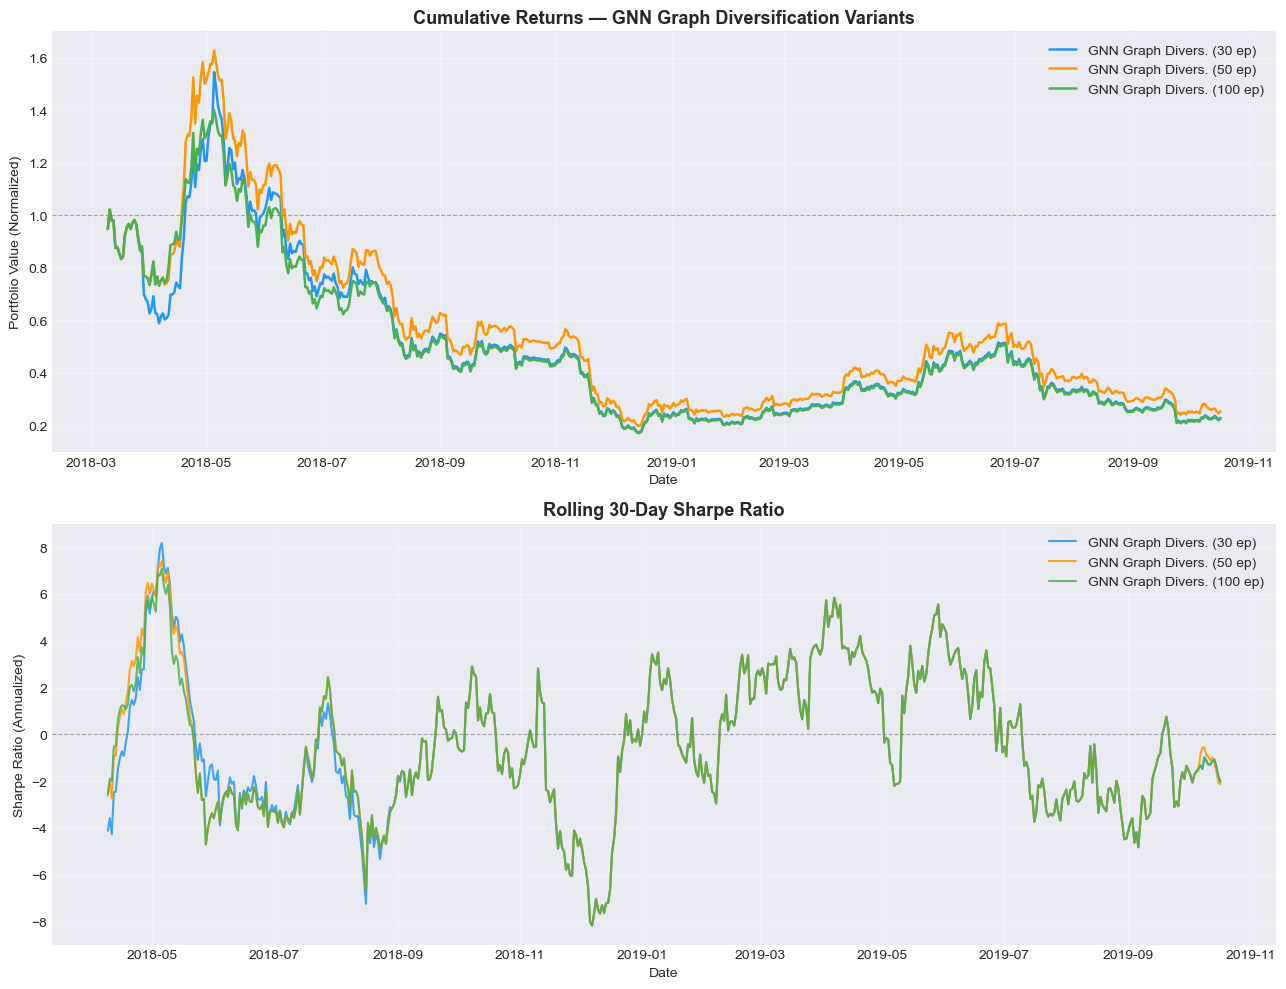

In [11]:
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# --- Plot 1: Cumulative Returns ---
ax1 = axes[0]
for (sname, res), color in zip(results.items(), colors):
    ax1.plot(res['dates'], res['cumulative_returns'],
             label=sname, color=color, linewidth=1.8)
ax1.axhline(y=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_title('Cumulative Returns — GNN Graph Diversification Variants', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Portfolio Value (Normalized)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Rolling Sharpe Ratio (30-day) ---
ax2 = axes[1]
for (sname, res), color in zip(results.items(), colors):
    returns_series = pd.Series(res['returns'], index=res['dates'])
    rolling_sharpe = (
        returns_series.rolling(30).mean() /
        returns_series.rolling(30).std()
    ) * np.sqrt(252)
    ax2.plot(rolling_sharpe.index, rolling_sharpe.values,
             label=sname, color=color, linewidth=1.5, alpha=0.85)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.set_title('Rolling 30-Day Sharpe Ratio', fontsize=13, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sharpe Ratio (Annualized)')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gnn_cumulative_returns.png', dpi=150)
plt.show()

---
## Sel 12 — Analisis per Sub-Periode (Bull / Bear / Recovery)

In [12]:
period_metrics = {}

for pname, pdf in periods.items():
    if len(pdf) < WINDOW_SIZE + 10:
        print(f'Skip {pname} — data terlalu sedikit ({len(pdf)} days)')
        continue

    period_results = {}
    print(f'\nBacktesting period: {pname} ({len(pdf)} days)')

    for sname, strategy in strategies.items():
        # Re-inisialisasi model agar fresh per periode
        strat = GNNGraphDiversification(
            name=strategy.name,
            train_epochs=strategy.train_epochs
        )
        period_results[sname] = backtest_strategy(
            strat, pdf,
            window_size=min(WINDOW_SIZE, len(pdf)//3),
            rebalance_freq=REBALANCE_FREQ,
            tc=TRANS_COST
        )

    period_metrics[pname] = pd.DataFrame(
        [calculate_metrics(r) for r in period_results.values()]
    ).set_index('Strategy')

print('\n✅ Analisis sub-periode selesai!')

# Tampilkan per periode
for pname, mdf in period_metrics.items():
    print(f'\n=== {pname} ===')
    print(mdf[['Total Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Calmar Ratio']].to_string())

Skip Bull (Nov-Dec 2017) — data terlalu sedikit (52 days)

Backtesting period: Bear (2018) (364 days)
Backtesting [GNN Graph Divers. (30 ep)] — 35 rebalancing windows...
  Step  10/35
  Step  20/35
  Step  30/35
  Done! Total observations: 244
Backtesting [GNN Graph Divers. (50 ep)] — 35 rebalancing windows...
  Step  10/35
  Step  20/35
  Step  30/35
  Done! Total observations: 244
Backtesting [GNN Graph Divers. (100 ep)] — 35 rebalancing windows...
  Step  10/35
  Step  20/35
  Step  30/35
  Done! Total observations: 244

Backtesting period: Recovery (2019) (290 days)
Backtesting [GNN Graph Divers. (30 ep)] — 28 rebalancing windows...
  Step  10/28
  Step  20/28
  Done! Total observations: 194
Backtesting [GNN Graph Divers. (50 ep)] — 28 rebalancing windows...
  Step  10/28
  Step  20/28
  Done! Total observations: 194
Backtesting [GNN Graph Divers. (100 ep)] — 28 rebalancing windows...
  Step  10/28
  Step  20/28
  Done! Total observations: 194

Backtesting period: Full Period (706 

---
## Sel 13 — Visualisasi Perbandingan Metrik antar Sub-Periode

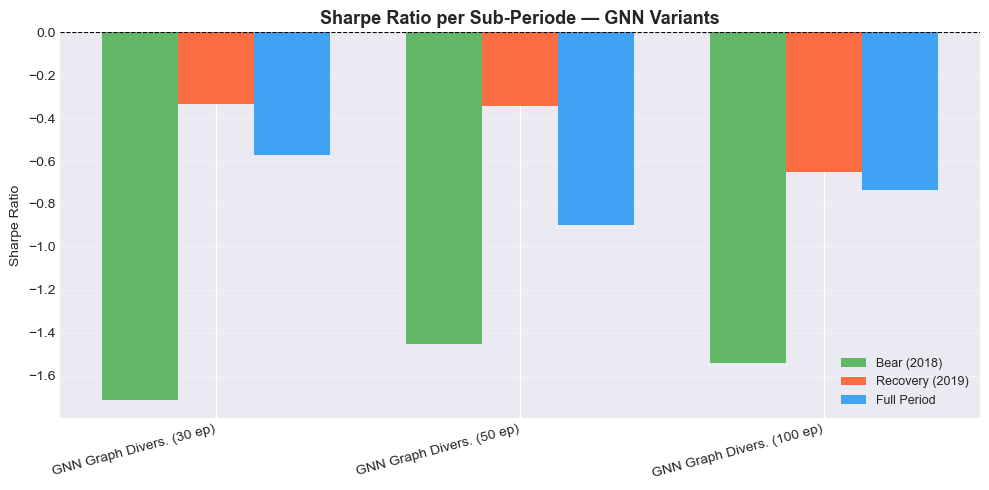

In [13]:
if period_metrics:
    metric_to_plot = 'Sharpe Ratio'
    plot_data = {
        pname: mdf[metric_to_plot]
        for pname, mdf in period_metrics.items()
    }
    plot_df = pd.DataFrame(plot_data)

    fig, ax = plt.subplots(figsize=(10, 5))
    x     = np.arange(len(plot_df.index))
    width = 0.25
    bar_colors = ['#4CAF50', '#FF5722', '#2196F3', '#9C27B0']

    for idx, (pname, col) in enumerate(plot_df.items()):
        ax.bar(x + idx * width, col.values, width,
               label=pname, color=bar_colors[idx], alpha=0.85)

    ax.set_xticks(x + width * (len(plot_df.columns) - 1) / 2)
    ax.set_xticklabels(plot_df.index, rotation=15, ha='right')
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{metric_to_plot} per Sub-Periode — GNN Variants', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric_to_plot)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('gnn_period_comparison.png', dpi=150)
    plt.show()

---
## Sel 14 — Diebold-Mariano Test (Signifikansi Statistik)

DM Test P-Value Matrix (p < 0.05 = signifikan)
                            GNN Graph Divers. (30 ep)  GNN Graph Divers. (50 ep)  GNN Graph Divers. (100 ep)
GNN Graph Divers. (30 ep)                      1.0000                     0.7053                      0.7900
GNN Graph Divers. (50 ep)                      0.7053                     1.0000                      0.3363
GNN Graph Divers. (100 ep)                     0.7900                     0.3363                      1.0000

DM Test Statistic Matrix (positif = baris mengalahkan kolom)
                            GNN Graph Divers. (30 ep)  GNN Graph Divers. (50 ep)  GNN Graph Divers. (100 ep)
GNN Graph Divers. (30 ep)                       0.000                     -0.378                       0.266
GNN Graph Divers. (50 ep)                       0.378                      0.000                       0.961
GNN Graph Divers. (100 ep)                     -0.266                     -0.961                       0.000


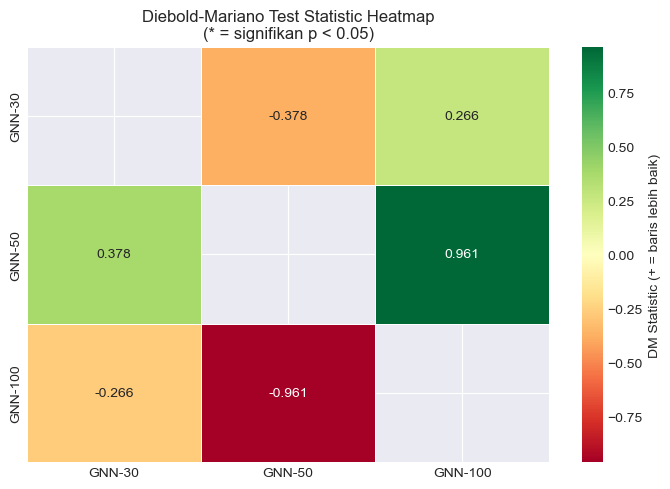

In [14]:
strategy_names = list(results.keys())

dm_stat_mat = pd.DataFrame(index=strategy_names, columns=strategy_names, dtype=float)
dm_pval_mat = pd.DataFrame(index=strategy_names, columns=strategy_names, dtype=float)

for i, s1 in enumerate(strategy_names):
    for j, s2 in enumerate(strategy_names):
        if i == j:
            dm_stat_mat.loc[s1, s2] = 0.0
            dm_pval_mat.loc[s1, s2] = 1.0
        else:
            dm, pv = diebold_mariano_test(
                results[s1]['returns'],
                results[s2]['returns']
            )
            dm_stat_mat.loc[s1, s2] = round(dm, 3)
            dm_pval_mat.loc[s1, s2] = round(pv, 4)

print('DM Test P-Value Matrix (p < 0.05 = signifikan)')
print(dm_pval_mat.to_string())
print()
print('DM Test Statistic Matrix (positif = baris mengalahkan kolom)')
print(dm_stat_mat.to_string())

# Heatmap DM Test
short_names = {
    'GNN Graph Divers. (30 ep)' : 'GNN-30',
    'GNN Graph Divers. (50 ep)' : 'GNN-50',
    'GNN Graph Divers. (100 ep)': 'GNN-100',
}

dm_stat_r = dm_stat_mat.rename(index=short_names, columns=short_names).astype(float)
pval_r    = dm_pval_mat.rename(index=short_names, columns=short_names).astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
mask_diag = np.eye(len(dm_stat_r), dtype=bool)

sns.heatmap(
    dm_stat_r, annot=True, fmt='.3f', center=0,
    cmap='RdYlGn', linewidths=0.5, ax=ax, mask=mask_diag,
    cbar_kws={'label': 'DM Statistic (+ = baris lebih baik)'}
)

for i in range(len(dm_stat_r)):
    for j in range(len(dm_stat_r.columns)):
        if i != j and pval_r.iloc[i, j] < 0.05:
            ax.text(j + 0.85, i + 0.15, '*', color='black',
                    fontsize=16, fontweight='bold')

plt.title('Diebold-Mariano Test Statistic Heatmap\n(* = signifikan p < 0.05)', fontsize=12)
plt.tight_layout()
plt.savefig('dm_test_heatmap_gnn.png', dpi=150)
plt.show()

---
## Sel 15 — Ringkasan Arsitektur & Kesimpulan

In [15]:
print('=' * 65)
print('   RINGKASAN ARSITEKTUR GNN GRAPH DIVERSIFICATION')
print('=' * 65)
print()
print('Model        : CorrelationGNN (2-layer GCN)')
print('Input Dim    : 4 node features (Mean, Std, Skew, Kurtosis)')
print('Hidden Dim   : 16')
print('Output Dim   : 8 (latent embedding)')
print('Optimizer    : Adam (lr=0.01)')
print('Loss         : MSE (predicted corr vs empirical corr)')
print('Selection    : Maximum Independent Set (MIS) pada graf GNN')
print('Allocation   : Equal Weight pada aset terpilih')
print()
print('Varian yang diuji:')
print('  - GNN-30  : 30 epoch per window')
print('  - GNN-50  : 50 epoch per window')
print('  - GNN-100 : 100 epoch per window')
print()
print('Backtesting Config:')
print(f'  Window Size    : {WINDOW_SIZE} hari')
print(f'  Rebalance Freq : {REBALANCE_FREQ} hari (mingguan)')
print(f'  Trans. Cost    : {TRANS_COST*100:.1f}%')
print()
print('METRIK FINAL (Full Period):')
print(metrics_df[['Total Return (%)', 'Sharpe Ratio',
                   'Max Drawdown (%)', 'Calmar Ratio']].to_string())
print('=' * 65)

   RINGKASAN ARSITEKTUR GNN GRAPH DIVERSIFICATION

Model        : CorrelationGNN (2-layer GCN)
Input Dim    : 4 node features (Mean, Std, Skew, Kurtosis)
Hidden Dim   : 16
Output Dim   : 8 (latent embedding)
Optimizer    : Adam (lr=0.01)
Loss         : MSE (predicted corr vs empirical corr)
Selection    : Maximum Independent Set (MIS) pada graf GNN
Allocation   : Equal Weight pada aset terpilih

Varian yang diuji:
  - GNN-30  : 30 epoch per window
  - GNN-50  : 50 epoch per window
  - GNN-100 : 100 epoch per window

Backtesting Config:
  Window Size    : 120 hari
  Rebalance Freq : 7 hari (mingguan)
  Trans. Cost    : 0.1%

METRIK FINAL (Full Period):
                            Total Return (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio
Strategy                                                                                  
GNN Graph Divers. (30 ep)             -77.13       -0.4922            -88.75       -0.4067
GNN Graph Divers. (50 ep)             -74.64       -0.4529         